In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycountry
import statsmodels.api as sm

### V-Dem + EVS/WVS datasets preparartion

In [2]:
democracy = pd.read_csv(r"C:\Users\Ксения\Downloads\democracy.csv")  # Load V-Dem dataset
democracy = democracy.loc[:, ["country_name", "country_text_id", "year", "v2x_polyarchy", "v2x_libdem"]]  # Keep only the variables needed for the project
democracy["year"] = pd.to_numeric(democracy["year"], errors="coerce")
democracy = democracy[democracy["year"] >= 2017]  # Restrict the dataset to the years covered by the project

democracy.head()

,country_name,country_text_id,year,v2x_polyarchy,v2x_libdem
228,Mexico,MEX,2017,0.635,0.439
229,Mexico,MEX,2018,0.675,0.455
230,Mexico,MEX,2019,0.685,0.434
231,Mexico,MEX,2020,0.663,0.406
232,Mexico,MEX,2021,0.618,0.370


In [3]:
values = pd.read_csv(r"C:\Users\Ксения\Downloads\values.csv", low_memory=False)  # Load EVS/WVS dataset
values = values.loc[:, ["study", "cntry", "cntry_AN", "year", "gwght", "F119"]]  # Keep only the variables needed for the project

# Make sure to convert the key variables to numeric format
values["F119"] = pd.to_numeric(values["F119"], errors="coerce")
values["gwght"] = pd.to_numeric(values["gwght"], errors="coerce")
values["year"] = pd.to_numeric(values["year"], errors="coerce")

values = values[values["F119"].between(1, 10)]  # Keep only valid answers on the 1-10 justifiability scale
values = values.dropna(subset=["cntry_AN", "year", "F119"])  # Drop observations with missing country, year, or attitude values

values.head()

,study,cntry,cntry_AN,year,gwght,F119
0,1,8,AL,2018,0.838214,1
1,1,8,AL,2018,0.481554,10
2,1,8,AL,2018,1.349687,1
3,1,8,AL,2018,0.972985,1
4,1,8,AL,2018,0.828971,1


In [4]:
# Weighted mean by study-country-year
values = (
    values
    .groupby(["study", "cntry_AN", "year"], as_index=False)
    .apply(lambda g: pd.Series({
        "F119_mean": (g["F119"] * g["gwght"]).sum() / g["gwght"].sum(),
        "n_obs": g["F119"].notna().sum()
    }))
    .reset_index(drop=True)
)

# If the same country-year appears twice, keep the study with more observations
values = values.sort_values(
    ["cntry_AN", "year", "n_obs"],
    ascending=[True, True, False]
)

values = values.drop_duplicates(
    subset=["cntry_AN", "year"],
    keep="first"
).copy()

values.head()

C:\Users\Ксения\AppData\Local\Temp\ipykernel_28208\1525381146.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,study,cntry_AN,year,F119_mean,n_obs
36,2,AD,2018,4.734940,996.0
0,1,AL,2018,1.643495,1423.0
1,1,AM,2018,2.174242,1488.0
37,2,AM,2021,1.451068,1212.0
38,2,AR,2017,3.808077,919.0


In [5]:
# Convert alpha-2 to alpha-3
def alpha2_to_alpha3(code):
    special = {"TW": "TWN", "HK": "HKG", "MO": "MAC", "NIR": None, "PR": None}
    if code in special:
        return special[code]
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

values["country_text_id"] = values["cntry_AN"].apply(alpha2_to_alpha3)

values.head()

,study,cntry_AN,year,F119_mean,n_obs,country_text_id
36,2,AD,2018,4.734940,996.0,AND
0,1,AL,2018,1.643495,1423.0,ALB
1,1,AM,2018,2.174242,1488.0,ARM
37,2,AM,2021,1.451068,1212.0,ARM
38,2,AR,2017,3.808077,919.0,ARG


In [6]:
dem_val = values.merge(
    democracy,
    on=["country_text_id", "year"],
    how="left"
)

dem_val.head()

,study,cntry_AN,year,F119_mean,n_obs,country_text_id,country_name,v2x_polyarchy,v2x_libdem
0,2,AD,2018,4.734940,996.0,AND,NaN,NaN,NaN
1,1,AL,2018,1.643495,1423.0,ALB,Albania,0.523,0.432
2,1,AM,2018,2.174242,1488.0,ARM,Armenia,0.522,0.404
3,2,AM,2021,1.451068,1212.0,ARM,Armenia,0.726,0.538
4,2,AR,2017,3.808077,919.0,ARG,Argentina,0.754,0.612


### UNAIDS dataset preparation

In [7]:
policy_raw = pd.read_csv(
    r"C:\Users\Ксения\Downloads\sex_work_policy.csv", sep=";", header=None, engine="python", encoding="cp1251")

policy_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,42,43,44,45,46,47,48,49,50,51
0,Столбец1,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,...,Column43,Column44,Column45,Column46,Column47,Column48,Column49,Column50,Column51,Column52
1,Country,Criminalization of sex work,Profiting from organizing and/or managing sexu...,Profiting from organizing and/or managing sexu...,Profiting from organizing and/or managing sexu...,Profiting from organizing and/or managing sexu...,Profiting from organizing and/or managing sexu...,Selling and buying sexual services is criminal...,Selling and buying sexual services is criminal...,Selling and buying sexual services is criminal...,...,Sex work is not subject to punitive regulation...,Sex work is not subject to punitive regulation...,Sex work is not subject to punitive regulation...,Sex work is not subject to punitive regulation...,Sex work is not subject to punitive regulation...,Issue is determined/differs at subnational lev...,Issue is determined/differs at subnational lev...,Issue is determined/differs at subnational lev...,Issue is determined/differs at subnational lev...,Issue is determined/differs at subnational lev...
2,year,NaN,2017,2018,2019,2021,2022,2017,2018,2019,...,2017,2018,2019,2021,2022,2017,2018,2019,2021,2022
3,Afghanistan,Yes [UNAIDS National Commitments and Policy In...,NaN,NaN,Yes [UNAIDS National Commitments and Policy In...,NaN,Yes [UNAIDS National Commitments and Policy In...,Yes [UNAIDS National Commitments and Policy In...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Albania,Yes [UNAIDS National Commitments and Policy In...,NaN,NaN,Yes [UNAIDS National Commitments and Policy In...,Yes [UNAIDS National Commitments and Policy In...,Yes [UNAIDS National Commitments and Policy In...,Yes [UNAIDS National Commitments and Policy In...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Row 1 has indicator names and row 2 has years
ind_row = policy_raw.iloc[1].tolist()
year_row = policy_raw.iloc[2].tolist()

policy = policy_raw.iloc[3:].reset_index(drop=True)

cols = []
for i, (ind, yr) in enumerate(zip(ind_row, year_row)):
    if i == 0:
        cols.append(("country", np.nan))
    elif i == 1:
        cols.append(("criminalization_overall_raw", np.nan))
    else:
        cols.append((ind, yr))

policy.columns = pd.MultiIndex.from_tuples(cols)

policy.head()

country                        criminalization_overall_raw  \
           NaN                                                NaN   
0  Afghanistan  Yes [UNAIDS National Commitments and Policy In...   
1      Albania  Yes [UNAIDS National Commitments and Policy In...   
2      Algeria  Yes [Algeria. Penal Code, Article 343 (https:/...   
3      Andorra                                                NaN   
4       Angola  No [Angola. Codigo Penal. I S?rie, Number 179....   

  Profiting from organizing and/or managing sexual services is criminalized  \
                                                                       2017   
0                                                NaN                          
1                                                NaN                          
2                                                NaN                          
3                                                NaN                          
4                                                NaN                          

                                                           \
  2018                                               2019   
0  NaN  Yes [UNAIDS National Commitments and Policy In...   
1  NaN  Yes [UNAIDS National Commitments and Policy In...   
2  NaN                                                NaN   
3  NaN                                                NaN   
4  NaN                                                NaN   

                                                      \
                                                2021   
0                                                NaN   
1  Yes [UNAIDS National Commitments and Policy In...   
2                                                NaN   
3                                                NaN   
4  Yes [Angola. Codigo Penal. Article 189 (https:...   

                                                      \
                                                2022   
0  Yes [UNAIDS National Commitments and Policy In...   
1  Yes [UNAIDS National Commitments and Policy In...   
2  Yes [Algeria. Penal Code, Article 343 (https:/...   
3                                                NaN   
4                                                NaN   

  Selling and buying sexual services is criminalized**            ...  \
                                                  2017 2018 2019  ...   
0  Yes [UNAIDS National Commitments and Policy In...    NaN  NaN  ...   
1  Yes [UNAIDS National Commitments and Policy In...    NaN  NaN  ...   
2                                                NaN    NaN  NaN  ...   
3                                                NaN    NaN  NaN  ...   
4                                                NaN    NaN  NaN  ...   

  Sex work is not subject to punitive regulations and is not criminalized  \
                                                                     2017   
0                                                NaN                        
1                                                NaN                        
2                                                NaN                        
3                                                NaN                        
4                                                NaN                        

                                                                     \
  2018 2019 2021                                               2022   
0  NaN  NaN  NaN                                                NaN   
1  NaN  NaN  NaN                                                NaN   
2  NaN  NaN  NaN                                                NaN   
3  NaN  NaN  NaN                                                NaN   
4  NaN  NaN  NaN  Yes [Angola. Codigo Penal. I S?rie, Number 179...   

  Issue is determined/differs at subnational level**                      
                                                2017 2018 2019 2021 2022  
0                                                NaN  N

In [9]:
# Extract variable on criminalization of sex work
overall = pd.DataFrame({
    "country": policy[("country", np.nan)],
    "criminalization_overall_raw": policy[("criminalization_overall_raw", np.nan)]
})

def parse_general(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x.startswith("yes"):
        return 1
    elif x.startswith("no"):
        return 0
    elif x.startswith("not stated"):
        return np.nan
    else:
        return np.nan

overall["criminalization_overall_fallback"] = overall["criminalization_overall_raw"].apply(parse_general)
overall = overall.drop_duplicates(subset=["country"]).copy()

overall.head()

,country,criminalization_overall_raw,criminalization_overall_fallback
0,Afghanistan,Yes [UNAIDS National Commitments and Policy In...,1.0
1,Albania,Yes [UNAIDS National Commitments and Policy In...,1.0
2,Algeria,"Yes [Algeria. Penal Code, Article 343 (https:/...",1.0
3,Andorra,NaN,NaN
4,Angola,"No [Angola. Codigo Penal. I S?rie, Number 179....",0.0


In [10]:
# Shorter names for the legal indicators
rename_map = {
    "Profiting from organizing and/or managing sexual services is criminalized": "organizing_criminalized",
    "Selling and buying sexual services is criminalized**": "selling_and_buying_criminalized",
    "Selling sexual services is criminalized": "selling_criminalized",
    "Buying sexual services is criminalized": "buying_criminalized",
    "Partial criminalization of sex work**": "partial_criminalization",
    "Ancillary activities associated with selling sexual services are criminalized": "ancillary_selling_criminalized",
    "Ancillary activities associated with buying sexual services are criminalized": "ancillary_buying_criminalized",
    "Other punitive and/or administrative regulation of sex work": "other_punitive_regulation",
    "Sex work is not subject to punitive regulations and is not criminalized": "not_criminalized",
    "Issue is determined/differs at subnational level**": "subnational_variation"
}

rows = []

for col in policy.columns:
    ind, yr = col

    if ind in ["country", "criminalization_overall_raw"]:
        continue

    ind_short = rename_map.get(ind, ind)
    s = policy[col]

    temp = pd.DataFrame({
        "country": policy[("country", np.nan)],
        "year": pd.to_numeric(yr, errors="coerce"),
        "indicator": ind_short,
        "raw_value": s
    })

    temp["present"] = np.where(s.notna() & (s.astype(str).str.strip() != ""), 1, 0)
    rows.append(temp)

policy_long = pd.concat(rows, ignore_index=True)
policy_long.head()

,country,year,indicator,raw_value,present
0,Afghanistan,2017,organizing_criminalized,NaN,0
1,Albania,2017,organizing_criminalized,NaN,0
2,Algeria,2017,organizing_criminalized,NaN,0
3,Andorra,2017,organizing_criminalized,NaN,0
4,Angola,2017,organizing_criminalized,NaN,0


In [11]:
policy_wide = policy_long.pivot_table(
    index=["country", "year"],
    columns="indicator",
    values="present",
    aggfunc="max",
    fill_value=0
).reset_index()

policy_wide.columns.name = None
policy_wide.head()

,country,year,ancillary_buying_criminalized,ancillary_selling_criminalized,buying_criminalized,not_criminalized,organizing_criminalized,other_punitive_regulation,partial_criminalization,selling_and_buying_criminalized,selling_criminalized,subnational_variation
0,Afghanistan,2017,0,0,0,0,0,0,0,1,0,0
1,Afghanistan,2018,0,0,0,0,0,0,0,0,0,0
2,Afghanistan,2019,1,1,1,0,1,1,0,0,1,0
3,Afghanistan,2021,0,1,1,0,0,1,0,0,1,0
4,Afghanistan,2022,1,1,1,0,1,1,0,0,1,0


In [12]:
need = [
    "selling_criminalized",
    "buying_criminalized",
    "selling_and_buying_criminalized",
    "ancillary_selling_criminalized",
    "ancillary_buying_criminalized",
    "not_criminalized",
    "partial_criminalization",
    "organizing_criminalized",
    "other_punitive_regulation",
    "subnational_variation"
]

for col in need:
    if col not in policy_wide.columns:
        policy_wide[col] = 0

In [13]:
policy_wide = policy_wide.merge(
    overall.loc[:, ["country", "criminalization_overall_fallback"]],
    on="country",
    how="left"
)

policy_wide.head()

,country,year,ancillary_buying_criminalized,ancillary_selling_criminalized,buying_criminalized,not_criminalized,organizing_criminalized,other_punitive_regulation,partial_criminalization,selling_and_buying_criminalized,selling_criminalized,subnational_variation,criminalization_overall_fallback
0,Afghanistan,2017,0,0,0,0,0,0,0,1,0,0,1.0
1,Afghanistan,2018,0,0,0,0,0,0,0,0,0,0,1.0
2,Afghanistan,2019,1,1,1,0,1,1,0,0,1,0,1.0
3,Afghanistan,2021,0,1,1,0,0,1,0,0,1,0,1.0
4,Afghanistan,2022,1,1,1,0,1,1,0,0,1,0,1.0


In [14]:
# Create positive markers for seller side, buyer side, and overall punitive regime
seller_pos = (
    (policy_wide["selling_criminalized"] == 1) |
    (policy_wide["ancillary_selling_criminalized"] == 1) |
    (policy_wide["selling_and_buying_criminalized"] == 1)
)

buyer_pos = (
    (policy_wide["buying_criminalized"] == 1) |
    (policy_wide["ancillary_buying_criminalized"] == 1) |
    (policy_wide["selling_and_buying_criminalized"] == 1)
)

noncrim_pos = (policy_wide["not_criminalized"] == 1)
overall_crim = (policy_wide["criminalization_overall_fallback"] == 1)
overall_noncrim = (policy_wide["criminalization_overall_fallback"] == 0)

# Seller-side punitive
seller_zero_from_overall = (
    overall_crim &
    (policy_wide["selling_criminalized"] == 0) &
    (policy_wide["ancillary_selling_criminalized"] == 0) &
    (policy_wide["selling_and_buying_criminalized"] == 0)
)

policy_wide["seller_side_punitive_strict"] = np.where(
    seller_pos,
    1,
    np.where(
        noncrim_pos | seller_zero_from_overall,
        0,
        np.nan
    )
)

# Buyer-side punitive
buyer_zero_from_overall = (
    overall_crim &
    (policy_wide["buying_criminalized"] == 0) &
    (policy_wide["ancillary_buying_criminalized"] == 0) &
    (policy_wide["selling_and_buying_criminalized"] == 0)
)

policy_wide["buyer_side_punitive_strict"] = np.where(
    buyer_pos,
    1,
    np.where(
        noncrim_pos | buyer_zero_from_overall,
        0,
        np.nan
    )
)

# Overall punitive regime
overall_pos = (
    (policy_wide["selling_and_buying_criminalized"] == 1) |
    (policy_wide["selling_criminalized"] == 1) |
    (policy_wide["buying_criminalized"] == 1) |
    (policy_wide["partial_criminalization"] == 1) |
    (policy_wide["organizing_criminalized"] == 1) |
    (policy_wide["other_punitive_regulation"] == 1) |
    (policy_wide["ancillary_selling_criminalized"] == 1) |
    (policy_wide["ancillary_buying_criminalized"] == 1) |
    overall_crim
)

policy_wide["overall_punitive_regime"] = np.where(overall_pos, 1,np.where(noncrim_pos | overall_noncrim, 0, np.nan))

for var in ["seller_side_punitive_strict", "buyer_side_punitive_strict", "overall_punitive_regime"]:
    print("\n", var)
    print(policy_wide[var].value_counts(dropna=False))


 seller_side_punitive_strict
seller_side_punitive_strict
0.0    632
1.0    265
NaN     88
Name: count, dtype: int64

 buyer_side_punitive_strict
buyer_side_punitive_strict
0.0    722
1.0    174
NaN     89
Name: count, dtype: int64

 overall_punitive_regime
overall_punitive_regime
1.0    876
0.0     92
NaN     17
Name: count, dtype: int64


In [15]:
# Convert UNAIDS country names to ISO3
def country_to_iso3(name):
    if pd.isna(name):
        return np.nan

    name = str(name).strip()

    if name in ["]", "view).]", ""]:
        return np.nan

    special = {
        "Bolivia (Plurinational State of)": "BOL",
        "Cabo Verde": "CPV",
        "Congo": "COG",
        "Côte d’Ivoire": "CIV",
        "Côte d'Ivoire": "CIV",
        "C?te d'Ivoire": "CIV",
        "Democratic Republic of the Congo": "COD",
        "Eswatini": "SWZ",
        "Iran (Islamic Republic of)": "IRN",
        "Lao People's Democratic Republic": "LAO",
        "Micronesia (Federated States of)": "FSM",
        "Moldova (Republic of)": "MDA",
        "North Macedonia": "MKD",
        "Occupied Palestinian Territory": "PSE",
        "Palestine": "PSE",
        "Republic of Korea": "KOR",
        "Russian Federation": "RUS",
        "Syrian Arab Republic": "SYR",
        "Taiwan": "TWN",
        "Tanzania, United Republic of": "TZA",
        "Türkiye": "TUR",
        "Turkey": "TUR",
        "United Kingdom of Great Britain and Northern Ireland": "GBR",
        "United States of America": "USA",
        "Venezuela (Bolivarian Republic of)": "VEN",
        "Viet Nam": "VNM",
        "Kosovo": "XKX"
    }

    if name in special:
        return special[name]

    try:
        return pycountry.countries.lookup(name).alpha_3
    except:
        return np.nan

policy_wide["country_text_id"] = policy_wide["country"].apply(country_to_iso3)
policy = policy_wide.dropna(subset=["country_text_id"]).copy()
policy.head()

,country,year,ancillary_buying_criminalized,ancillary_selling_criminalized,buying_criminalized,not_criminalized,organizing_criminalized,other_punitive_regulation,partial_criminalization,selling_and_buying_criminalized,selling_criminalized,subnational_variation,criminalization_overall_fallback,seller_side_punitive_strict,buyer_side_punitive_strict,overall_punitive_regime,country_text_id
0,Afghanistan,2017,0,0,0,0,0,0,0,1,0,0,1.0,1.0,1.0,1.0,AFG
1,Afghanistan,2018,0,0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,1.0,AFG
2,Afghanistan,2019,1,1,1,0,1,1,0,0,1,0,1.0,1.0,1.0,1.0,AFG
3,Afghanistan,2021,0,1,1,0,0,1,0,0,1,0,1.0,1.0,1.0,1.0,AFG
4,Afghanistan,2022,1,1,1,0,1,1,0,0,1,0,1.0,1.0,1.0,1.0,AFG


### Merging

In [16]:
# Match each survey year to the nearest non-missing policy year for the same country
def build_sample(base, policy, var):
    left = base.copy()
    left["year"] = pd.to_numeric(left["year"], errors="coerce")
    left = left.dropna(subset=["country_text_id", "year"]).copy()
    left["year"] = left["year"].astype(int)

    right = policy.loc[:, ["country_text_id", "year", var]].copy()
    right["year"] = pd.to_numeric(right["year"], errors="coerce")
    right = right.dropna(subset=["country_text_id", "year", var]).copy()
    right["year"] = right["year"].astype(int)
    right = right.rename(columns={"year": "policy_year"})

    parts = []

    common = sorted(set(left["country_text_id"]) & set(right["country_text_id"]))

    for c in common:
        l = left[left["country_text_id"] == c].sort_values("year").reset_index(drop=True).copy()
        r = right[right["country_text_id"] == c].sort_values("policy_year").reset_index(drop=True).copy()

        r = r.drop(columns=["country_text_id"])

        m = pd.merge_asof(
            l,
            r,
            left_on="year",
            right_on="policy_year",
            direction="nearest",
            allow_exact_matches=True
        )

        m["country_text_id"] = c
        parts.append(m)

    no_match = left[~left["country_text_id"].isin(common)].copy()
    no_match["policy_year"] = np.nan
    no_match[var] = np.nan

    out = pd.concat(parts + [no_match], ignore_index=True)

    out["policy_year_gap"] = out["year"] - out["policy_year"]
    out["policy_abs_gap"] = out["policy_year_gap"].abs()
    out["policy_exact_year_match"] = np.where(
        out["year"] == out["policy_year"],
        1,
        0
    )

    return out

seller = build_sample(values, policy, "seller_side_punitive_strict")
buyer = build_sample(values, policy, "buyer_side_punitive_strict")
policy_all = build_sample(values, policy, "overall_punitive_regime")

In [17]:
for name, df, var in [
    ("seller", seller, "seller_side_punitive_strict"),
    ("buyer", buyer, "buyer_side_punitive_strict"),
    ("overall", policy_all, "overall_punitive_regime")]:
    print("\n===================")
    print(name)
    print("===================")
    print(df[var].value_counts(dropna=False))
    print(df["policy_exact_year_match"].value_counts(dropna=False))
    print(df["policy_abs_gap"].value_counts(dropna=False).sort_index())


seller
seller_side_punitive_strict
0.0    69
1.0    17
NaN     6
Name: count, dtype: int64
policy_exact_year_match
1    63
0    29
Name: count, dtype: int64
policy_abs_gap
0.0    63
1.0    18
2.0     2
3.0     1
5.0     2
NaN     6
Name: count, dtype: int64

buyer
buyer_side_punitive_strict
0.0    75
1.0    11
NaN     6
Name: count, dtype: int64
policy_exact_year_match
1    63
0    29
Name: count, dtype: int64
policy_abs_gap
0.0    63
1.0    18
2.0     2
3.0     1
5.0     2
NaN     6
Name: count, dtype: int64

overall
overall_punitive_regime
1.0    78
0.0    10
NaN     4
Name: count, dtype: int64
policy_exact_year_match
1    73
0    19
Name: count, dtype: int64
policy_abs_gap
0.0    73
1.0    15
NaN     4
Name: count, dtype: int64


In [18]:
seller = seller.merge(
    democracy.loc[:, ["country_text_id", "year", "country_name", "v2x_polyarchy", "v2x_libdem"]],
    on=["country_text_id", "year"],
    how="left"
)

buyer = buyer.merge(
    democracy.loc[:, ["country_text_id", "year", "country_name", "v2x_polyarchy", "v2x_libdem"]],
    on=["country_text_id", "year"],
    how="left"
)

policy_all = policy_all.merge(
    democracy.loc[:, ["country_text_id", "year", "country_name", "v2x_polyarchy", "v2x_libdem"]],
    on=["country_text_id", "year"],
    how="left"
)

seller.head()

,study,cntry_AN,year,F119_mean,n_obs,country_text_id,policy_year,seller_side_punitive_strict,policy_year_gap,policy_abs_gap,policy_exact_year_match,country_name,v2x_polyarchy,v2x_libdem
0,1,AL,2018,1.643495,1423.0,ALB,2018.0,0.0,0.0,0.0,1,Albania,0.523,0.432
1,2,AR,2017,3.808077,919.0,ARG,2019.0,1.0,-2.0,2.0,0,Argentina,0.754,0.612
2,1,AM,2018,2.174242,1488.0,ARM,2018.0,0.0,0.0,0.0,1,Armenia,0.522,0.404
3,2,AM,2021,1.451068,1212.0,ARM,2021.0,0.0,0.0,0.0,1,Armenia,0.726,0.538
4,2,AU,2018,5.281014,1765.0,AUS,2018.0,0.0,0.0,0.0,1,Australia,0.858,0.813


In [19]:
# final datasets
seller_df = seller.dropna(subset=["F119_mean", "v2x_libdem", "seller_side_punitive_strict"]).copy()
buyer_df = buyer.dropna(subset=["F119_mean", "v2x_libdem", "buyer_side_punitive_strict"]).copy()
policy_df = policy_all.dropna(subset=["F119_mean", "v2x_libdem", "overall_punitive_regime"]).copy()

print("seller_df:", len(seller_df))
print("buyer_df:", len(buyer_df))
print("policy_df:", len(policy_df))

seller_df: 86
buyer_df: 86
policy_df: 88


### Analysis

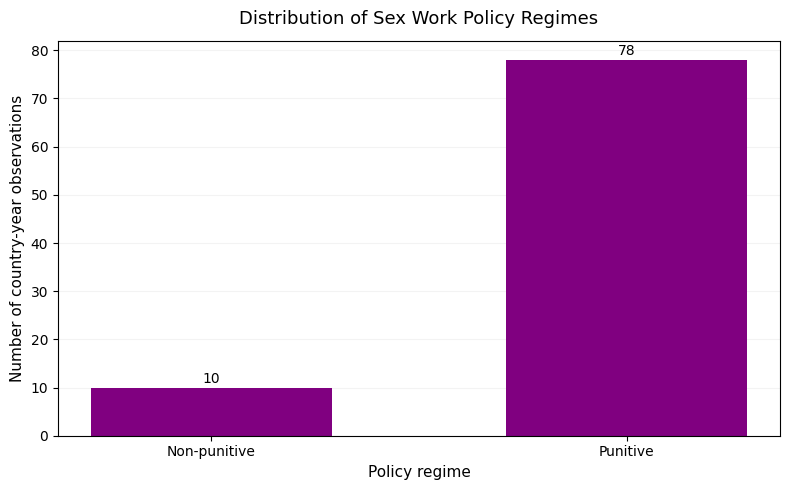

In [20]:
# Count how many observations fall into each policy category
policy_counts = (
    policy_df["overall_punitive_regime"]
    .value_counts()
    .sort_index()
)

# Rename the categories to make the plot readable
policy_counts.index = ["Non-punitive", "Punitive"]

# Bar chart of policy distribution
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    policy_counts.index,
    policy_counts.values,
    color="purple",
    width=0.58
)

# Add counts above the bars
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + 0.3,
        f"{int(h)}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )

ax.set_title("Distribution of Sex Work Policy Regimes", fontsize=13, pad=12)
ax.set_xlabel("Policy regime", fontsize=11)
ax.set_ylabel("Number of country-year observations", fontsize=11)

ax.set_ylim(0, 82)
ax.grid(True, axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\policy_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

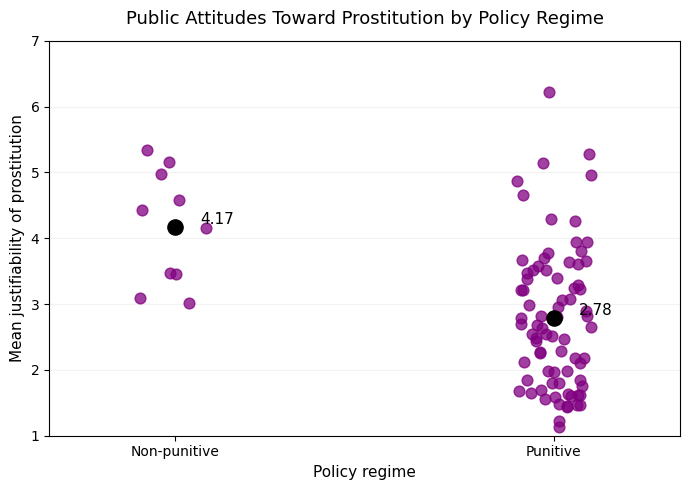

In [21]:
# Keep only observations with non-missing values 
plot_df = policy_df.dropna(subset=["overall_punitive_regime", "F119_mean"]).copy()

# Split the data into 2groups
non_pun = plot_df[plot_df["overall_punitive_regime"] == 0].copy()
pun = plot_df[plot_df["overall_punitive_regime"] == 1].copy()

# Set x positions 
non_pun["x"] = 0.25
pun["x"] = 0.55

# Add a little horizontal jitter
non_pun["x_jitter"] = non_pun["x"] + np.random.uniform(-0.03, 0.03, size=len(non_pun))
pun["x_jitter"] = pun["x"] + np.random.uniform(-0.03, 0.03, size=len(pun))

# Calculate group means
mean_non_pun = non_pun["F119_mean"].mean()
mean_pun = pun["F119_mean"].mean()

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    non_pun["x_jitter"],
    non_pun["F119_mean"],
    s=60,
    color="purple",
    alpha=0.75
)

ax.scatter(
    pun["x_jitter"],
    pun["F119_mean"],
    s=60,
    color="purple",
    alpha=0.75
)

# Add mean points
ax.scatter(0.25, mean_non_pun, s=120, color="black", zorder=5)
ax.scatter(0.55, mean_pun, s=120, color="black", zorder=5)

# Add mean labels
ax.text(0.27, mean_non_pun + 0.05, f"{mean_non_pun:.2f}", fontsize=11, color="black")
ax.text(0.57, mean_pun + 0.05, f"{mean_pun:.2f}", fontsize=11, color="black")

ax.set_title("Public Attitudes Toward Prostitution by Policy Regime", fontsize=13, pad=12)
ax.set_xlabel("Policy regime", fontsize=11)
ax.set_ylabel("Mean justifiability of prostitution", fontsize=11)

ax.set_xticks([0.25, 0.55])
ax.set_xticklabels(["Non-punitive", "Punitive"])

ax.set_ylim(1, 7)
ax.set_xlim(0.15, 0.65)

ax.grid(True, axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\values_by_policy.png", dpi=300, bbox_inches="tight")
plt.show()

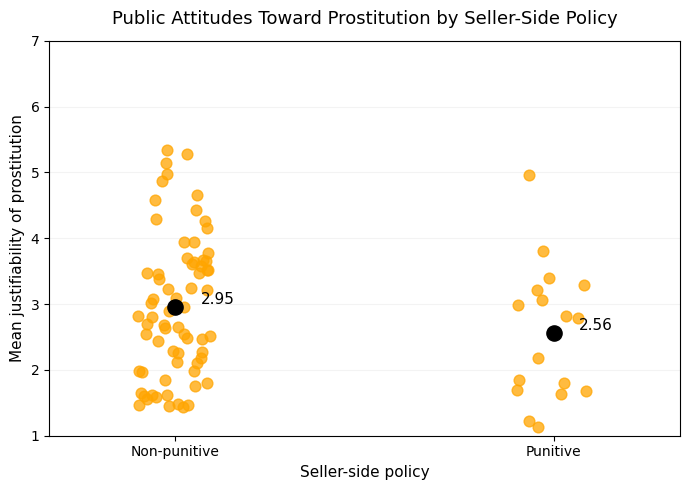

In [22]:
# Same for seller-side policy
plot_df = seller_df.dropna(subset=["seller_side_punitive_strict", "F119_mean"]).copy()

non_pun = plot_df[plot_df["seller_side_punitive_strict"] == 0].copy()
pun = plot_df[plot_df["seller_side_punitive_strict"] == 1].copy()

non_pun["x"] = 0.25
pun["x"] = 0.55

non_pun["x_jitter"] = non_pun["x"] + np.random.uniform(-0.03, 0.03, size=len(non_pun))
pun["x_jitter"] = pun["x"] + np.random.uniform(-0.03, 0.03, size=len(pun))

mean_non_pun = non_pun["F119_mean"].mean()
mean_pun = pun["F119_mean"].mean()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    non_pun["x_jitter"],
    non_pun["F119_mean"],
    s=60,
    color="orange",
    alpha=0.75
)

ax.scatter(
    pun["x_jitter"],
    pun["F119_mean"],
    s=60,
    color="orange",
    alpha=0.75
)

ax.scatter(0.25, mean_non_pun, s=120, color="black", zorder=5)
ax.scatter(0.55, mean_pun, s=120, color="black", zorder=5)

ax.text(0.27, mean_non_pun + 0.05, f"{mean_non_pun:.2f}", fontsize=11, color="black")
ax.text(0.57, mean_pun + 0.05, f"{mean_pun:.2f}", fontsize=11, color="black")

ax.set_title("Public Attitudes Toward Prostitution by Seller-Side Policy", fontsize=13, pad=12)
ax.set_xlabel("Seller-side policy", fontsize=11)
ax.set_ylabel("Mean justifiability of prostitution", fontsize=11)

ax.set_xticks([0.25, 0.55])
ax.set_xticklabels(["Non-punitive", "Punitive"])

ax.set_ylim(1, 7)
ax.set_xlim(0.15, 0.65)

ax.grid(True, axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\values_by_seller_policy.png", dpi=300, bbox_inches="tight")
plt.show()

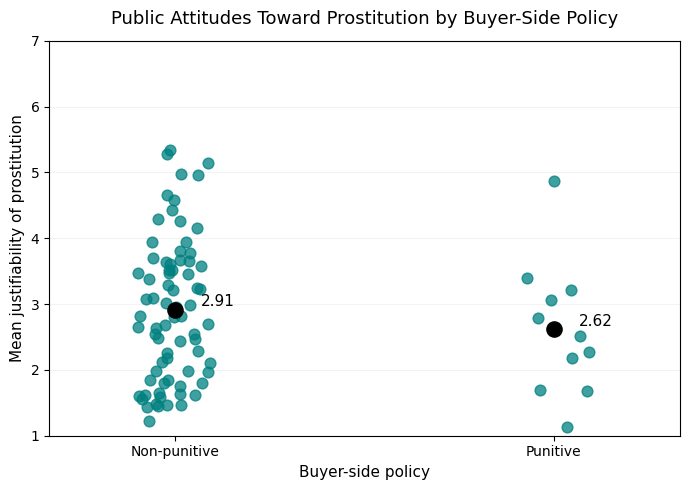

In [23]:
# Same for buyer-side policy
plot_df = buyer_df.dropna(subset=["buyer_side_punitive_strict", "F119_mean"]).copy()

non_pun = plot_df[plot_df["buyer_side_punitive_strict"] == 0].copy()
pun = plot_df[plot_df["buyer_side_punitive_strict"] == 1].copy()

non_pun["x"] = 0.25
pun["x"] = 0.55

non_pun["x_jitter"] = non_pun["x"] + np.random.uniform(-0.03, 0.03, size=len(non_pun))
pun["x_jitter"] = pun["x"] + np.random.uniform(-0.03, 0.03, size=len(pun))

mean_non_pun = non_pun["F119_mean"].mean()
mean_pun = pun["F119_mean"].mean()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    non_pun["x_jitter"],
    non_pun["F119_mean"],
    s=60,
    color="teal",
    alpha=0.75
)

ax.scatter(
    pun["x_jitter"],
    pun["F119_mean"],
    s=60,
    color="teal",
    alpha=0.75
)

ax.scatter(0.25, mean_non_pun, s=120, color="black", zorder=5)
ax.scatter(0.55, mean_pun, s=120, color="black", zorder=5)

ax.text(0.27, mean_non_pun + 0.05, f"{mean_non_pun:.2f}", fontsize=11, color="black")
ax.text(0.57, mean_pun + 0.05, f"{mean_pun:.2f}", fontsize=11, color="black")

ax.set_title("Public Attitudes Toward Prostitution by Buyer-Side Policy", fontsize=13, pad=12)
ax.set_xlabel("Buyer-side policy", fontsize=11)
ax.set_ylabel("Mean justifiability of prostitution", fontsize=11)

ax.set_xticks([0.25, 0.55])
ax.set_xticklabels(["Non-punitive", "Punitive"])

ax.set_ylim(1, 7)
ax.set_xlim(0.15, 0.65)

ax.grid(True, axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\values_by_buyer_policy.png", dpi=300, bbox_inches="tight")
plt.show()

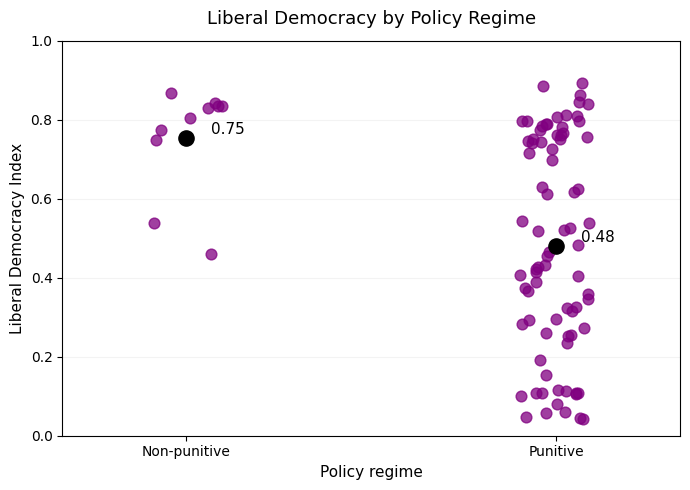

In [24]:
# Same for overall policy and democracy
plot_df = policy_df.dropna(subset=["overall_punitive_regime", "v2x_libdem"]).copy()

non_pun = plot_df[plot_df["overall_punitive_regime"] == 0].copy()
pun = plot_df[plot_df["overall_punitive_regime"] == 1].copy()

non_pun["x"] = 0.25
pun["x"] = 0.55

non_pun["x_jitter"] = non_pun["x"] + np.random.uniform(-0.03, 0.03, size=len(non_pun))
pun["x_jitter"] = pun["x"] + np.random.uniform(-0.03, 0.03, size=len(pun))

mean_non_pun = non_pun["v2x_libdem"].mean()
mean_pun = pun["v2x_libdem"].mean()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    non_pun["x_jitter"],
    non_pun["v2x_libdem"],
    s=60,
    color="purple",
    alpha=0.75
)

ax.scatter(
    pun["x_jitter"],
    pun["v2x_libdem"],
    s=60,
    color="purple",
    alpha=0.75
)

ax.scatter(0.25, mean_non_pun, s=120, color="black", zorder=5)
ax.scatter(0.55, mean_pun, s=120, color="black", zorder=5)

ax.text(0.27, mean_non_pun + 0.01, f"{mean_non_pun:.2f}", fontsize=11, color="black")
ax.text(0.57, mean_pun + 0.01, f"{mean_pun:.2f}", fontsize=11, color="black")

ax.set_title("Liberal Democracy by Policy Regime", fontsize=13, pad=12)
ax.set_xlabel("Policy regime", fontsize=11)
ax.set_ylabel("Liberal Democracy Index", fontsize=11)

ax.set_xticks([0.25, 0.55])
ax.set_xticklabels(["Non-punitive", "Punitive"])

ax.set_ylim(0, 1)
ax.set_xlim(0.15, 0.65)

ax.grid(True, axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\democracy_by_policy_regime.png", dpi=300, bbox_inches="tight")
plt.show()

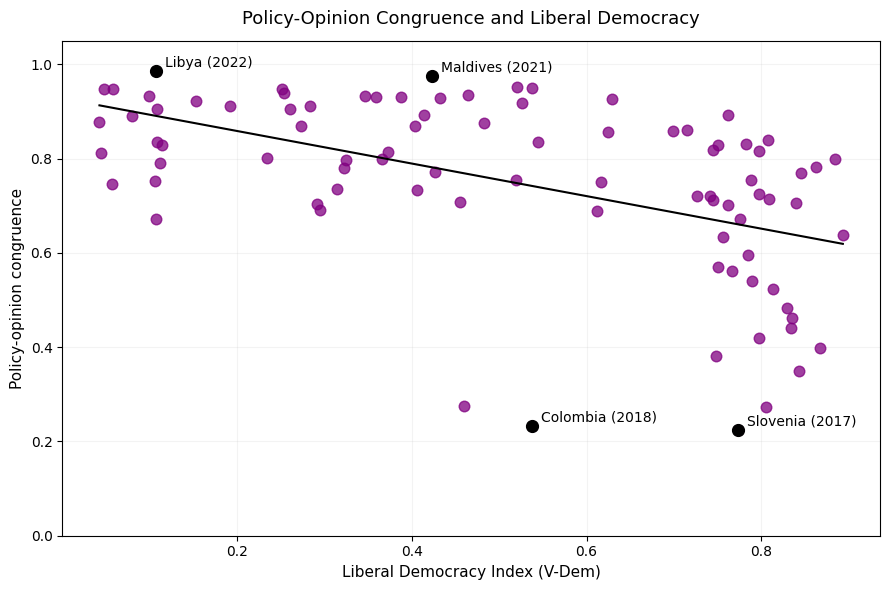

In [25]:
# Build a simple congruence measure

cong_df = policy_df.dropna(subset=["overall_punitive_regime", "F119_mean", "v2x_libdem", "country_name", "year"]).copy()

cong_df["attitude_punitive"] = (10 - cong_df["F119_mean"]) / 9
cong_df["incongruence"] = abs(cong_df["overall_punitive_regime"] - cong_df["attitude_punitive"])
cong_df["congruence"] = 1 - cong_df["incongruence"]

label_df = pd.concat([
    cong_df.nlargest(2, "congruence"),
    cong_df.nsmallest(2, "congruence")
]).drop_duplicates()

x = cong_df["v2x_libdem"]
y = cong_df["congruence"]
m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, s=58, color="purple", alpha=0.75)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color="black")

ax.scatter(label_df["v2x_libdem"], label_df["congruence"], s=72, color="black", zorder=5)

for _, row in label_df.iterrows():
    ax.text(
        row["v2x_libdem"] + 0.01,
        row["congruence"] + 0.01,
        f"{row['country_name']} ({int(row['year'])})",
        fontsize=10,
        color="black"
    )

ax.set_title("Policy-Opinion Congruence and Liberal Democracy", fontsize=13, pad=12)
ax.set_xlabel("Liberal Democracy Index (V-Dem)", fontsize=11)
ax.set_ylabel("Policy-opinion congruence", fontsize=11)

ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\congruence_vs_democracy.png", dpi=300, bbox_inches="tight")
plt.show()

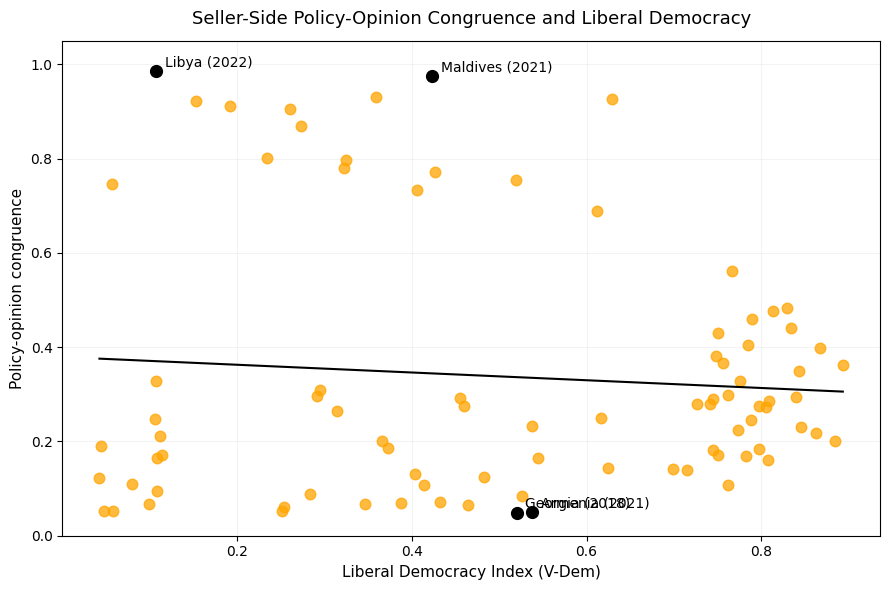

In [26]:
# Same for seller-side policy congruence

cong_df = seller_df.dropna(subset=["seller_side_punitive_strict", "F119_mean", "v2x_libdem", "country_name", "year"]).copy()

cong_df["attitude_punitive"] = (10 - cong_df["F119_mean"]) / 9
cong_df["incongruence"] = abs(cong_df["seller_side_punitive_strict"] - cong_df["attitude_punitive"])
cong_df["congruence"] = 1 - cong_df["incongruence"]

label_df = pd.concat([
    cong_df.nlargest(2, "congruence"),
    cong_df.nsmallest(2, "congruence")
]).drop_duplicates()

x = cong_df["v2x_libdem"]
y = cong_df["congruence"]
m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, s=58, color="orange", alpha=0.75)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color="black")

ax.scatter(label_df["v2x_libdem"], label_df["congruence"], s=72, color="black", zorder=5)

for _, row in label_df.iterrows():
    ax.text(
        row["v2x_libdem"] + 0.01,
        row["congruence"] + 0.01,
        f"{row['country_name']} ({int(row['year'])})",
        fontsize=10,
        color="black"
    )

ax.set_title("Seller-Side Policy-Opinion Congruence and Liberal Democracy", fontsize=13, pad=12)
ax.set_xlabel("Liberal Democracy Index (V-Dem)", fontsize=11)
ax.set_ylabel("Policy-opinion congruence", fontsize=11)

ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\seller_congruence_vs_democracy.png", dpi=300, bbox_inches="tight")
plt.show()

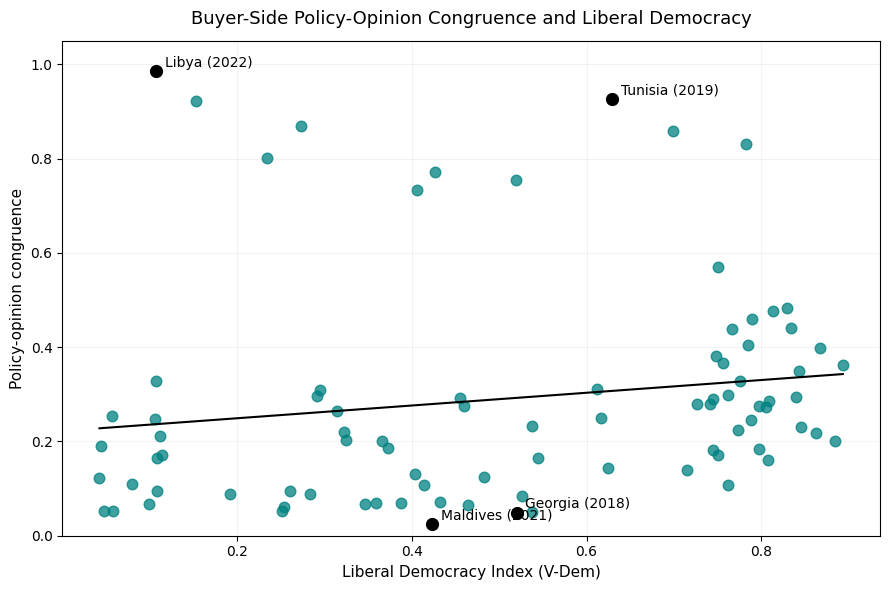

In [27]:
# Same for buyer-side policy congruence

cong_df = buyer_df.dropna(subset=["buyer_side_punitive_strict", "F119_mean", "v2x_libdem", "country_name", "year"]).copy()

cong_df["attitude_punitive"] = (10 - cong_df["F119_mean"]) / 9
cong_df["incongruence"] = abs(cong_df["buyer_side_punitive_strict"] - cong_df["attitude_punitive"])
cong_df["congruence"] = 1 - cong_df["incongruence"]

label_df = pd.concat([
    cong_df.nlargest(2, "congruence"),
    cong_df.nsmallest(2, "congruence")
]).drop_duplicates()

x = cong_df["v2x_libdem"]
y = cong_df["congruence"]
m, b = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, s=58, color="teal", alpha=0.75)

x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color="black")

ax.scatter(label_df["v2x_libdem"], label_df["congruence"], s=72, color="black", zorder=5)

for _, row in label_df.iterrows():
    ax.text(
        row["v2x_libdem"] + 0.01,
        row["congruence"] + 0.01,
        f"{row['country_name']} ({int(row['year'])})",
        fontsize=10,
        color="black"
    )

ax.set_title("Buyer-Side Policy-Opinion Congruence and Liberal Democracy", fontsize=13, pad=12)
ax.set_xlabel("Liberal Democracy Index (V-Dem)", fontsize=11)
ax.set_ylabel("Policy-opinion congruence", fontsize=11)

ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\buyer_congruence_vs_democracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [28]:
# Correlation between attitudes and democracy
policy_df[["F119_mean", "v2x_libdem"]].corr()

,F119_mean,v2x_libdem
F119_mean,1.000000,0.557166
v2x_libdem,0.557166,1.000000


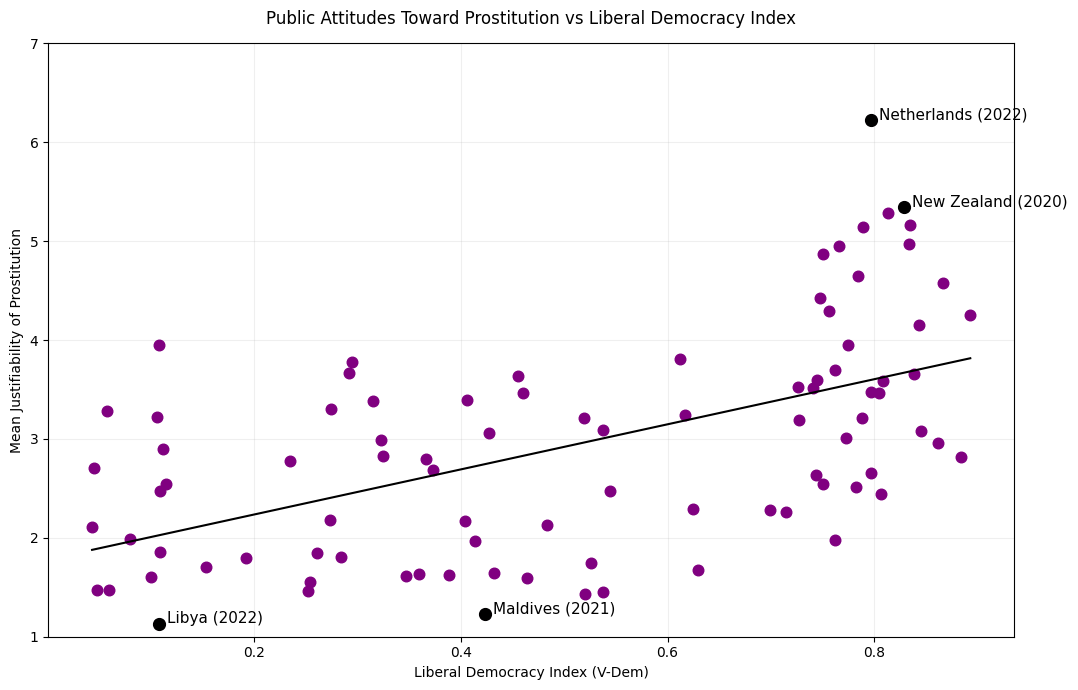

In [29]:
# Keep only observations with non-missing values needed for plotting
plot_df = dem_val.dropna(subset=["v2x_libdem", "F119_mean", "country_name", "year"]).copy()

# Select a few countries to label: top 2 and bottom 2 by average justifiability of prostitution
label_df = pd.concat([
    plot_df.nlargest(2, "F119_mean"),
    plot_df.nsmallest(2, "F119_mean")
]).drop_duplicates()

# Fit a simple linear trend line
x = plot_df["v2x_libdem"]
y = plot_df["F119_mean"]
m, b = np.polyfit(x, y, 1)

# Scatter plot with the trend line
fig, ax = plt.subplots(figsize=(11, 7))

ax.scatter(x, y, s=58, color="purple")
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color="black")
ax.set_ylim(1, 7)

# Highlight labeled countries
ax.scatter(label_df["v2x_libdem"], label_df["F119_mean"], s=72, color="black", zorder=5)

# Add country-year labels next to highlighted points
for _, row in label_df.iterrows():
    ax.text(
        row["v2x_libdem"] + 0.008,
        row["F119_mean"] + 0.008,
        f"{row['country_name']} ({int(row['year'])})",
        fontsize=11,
        color="black"
    )

ax.set_title("Public Attitudes Toward Prostitution vs Liberal Democracy Index", fontsize=12, pad=14)
ax.set_xlabel("Liberal Democracy Index (V-Dem)", fontsize=10)
ax.set_ylabel("Mean Justifiability of Prostitution", fontsize=10)

ax.grid(True, alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\PwD9.png")
plt.show()

In [30]:
# Main policy model with liberal democracy
model_df = policy_df.dropna(subset=["overall_punitive_regime", "F119_mean", "v2x_libdem"]).copy()

X = model_df[["F119_mean", "v2x_libdem"]].copy()
X = sm.add_constant(X)
y = model_df["overall_punitive_regime"]

model_policy_main = sm.Logit(y, X).fit(disp=False)
print(model_policy_main.summary())

print("\nOdds ratios:")
print(np.exp(model_policy_main.params))

                              Logit Regression Results                             
Dep. Variable:     overall_punitive_regime   No. Observations:                   88
Model:                               Logit   Df Residuals:                       85
Method:                                MLE   Df Model:                            2
Date:                     Fri, 01 May 2026   Pseudo R-squ.:                  0.2448
Time:                             06:39:29   Log-Likelihood:                -23.531
converged:                            True   LL-Null:                       -31.157
Covariance Type:                 nonrobust   LLR p-value:                 0.0004878
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9122      1.855      3.726      0.000       3.276      10.549
F119_mean     -0.7400      0.389     -1.903      0.057      -1.502       0.022
v2x_libdem  

In [31]:
# Main policy model with polyarchy
model_df = policy_df.dropna(subset=["overall_punitive_regime", "F119_mean", "v2x_polyarchy"]).copy()

X = model_df[["F119_mean", "v2x_polyarchy"]].copy()
X = sm.add_constant(X)
y = model_df["overall_punitive_regime"]

model_policy_poly = sm.Logit(y, X).fit(disp=False)
print(model_policy_poly.summary())

print("\nOdds ratios:")
print(np.exp(model_policy_poly.params))

                              Logit Regression Results                             
Dep. Variable:     overall_punitive_regime   No. Observations:                   88
Model:                               Logit   Df Residuals:                       85
Method:                                MLE   Df Model:                            2
Date:                     Fri, 01 May 2026   Pseudo R-squ.:                  0.2458
Time:                             06:39:29   Log-Likelihood:                -23.498
converged:                            True   LL-Null:                       -31.157
Covariance Type:                 nonrobust   LLR p-value:                 0.0004719
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9030      2.485      3.181      0.001       3.033      12.773
F119_mean        -0.7613      0.383     -1.990      0.047      -1.511      -0.012


In [32]:
table1 = pd.DataFrame({
    "Variable": ["Constant", "Mean justifiability of prostitution", "Liberal Democracy Index", "Electoral Democracy Index", "N", "Pseudo R-squared"],
    "Model 1": [
        f"{model_policy_main.params['const']:.3f} ({model_policy_main.bse['const']:.3f})",
        f"{model_policy_main.params['F119_mean']:.3f} ({model_policy_main.bse['F119_mean']:.3f})",
        f"{model_policy_main.params['v2x_libdem']:.3f} ({model_policy_main.bse['v2x_libdem']:.3f})",
        "",
        int(model_policy_main.nobs),
        f"{model_policy_main.prsquared:.3f}"
    ],
    "Model 2": [
        f"{model_policy_poly.params['const']:.3f} ({model_policy_poly.bse['const']:.3f})",
        f"{model_policy_poly.params['F119_mean']:.3f} ({model_policy_poly.bse['F119_mean']:.3f})",
        "",
        f"{model_policy_poly.params['v2x_polyarchy']:.3f} ({model_policy_poly.bse['v2x_polyarchy']:.3f})",
        int(model_policy_poly.nobs),
        f"{model_policy_poly.prsquared:.3f}"
    ]
})

table1

,Variable,Model 1,Model 2
0,Constant,6.912 (1.855),7.903 (2.485)
1,Mean justifiability of prostitution,-0.740 (0.389),-0.761 (0.383)
2,Liberal Democracy Index,-3.559 (2.552),
3,Electoral Democracy Index,,-4.328 (3.240)
4,N,88,88
5,Pseudo R-squared,0.245,0.246


In [33]:
# Seller-side policy model with liberal democracy index
model_df = seller_df.dropna(subset=["seller_side_punitive_strict", "F119_mean", "v2x_libdem"]).copy()

X = model_df[["F119_mean", "v2x_libdem"]].copy()
X = sm.add_constant(X)
y = model_df["seller_side_punitive_strict"]

model_policy_seller = sm.Logit(y, X).fit(disp=False)
print(model_policy_seller.summary())

print("\nOdds ratios:")
print(np.exp(model_policy_seller.params))

                                Logit Regression Results                               
Dep. Variable:     seller_side_punitive_strict   No. Observations:                   86
Model:                                   Logit   Df Residuals:                       83
Method:                                    MLE   Df Model:                            2
Date:                         Fri, 01 May 2026   Pseudo R-squ.:                 0.07464
Time:                                 06:39:29   Log-Likelihood:                -39.565
converged:                                True   LL-Null:                       -42.756
Covariance Type:                     nonrobust   LLR p-value:                   0.04112
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1454      0.813     -0.179      0.858      -1.738       1.448
F119_mean     -0.0468      0.328     -0.142      0.887     

In [34]:
# Seller-side policy model with polyarchy

model_df = seller_df.dropna(subset=["seller_side_punitive_strict", "F119_mean", "v2x_polyarchy"]).copy()

X = model_df[["F119_mean", "v2x_polyarchy"]].copy()
X = sm.add_constant(X)
y = model_df["seller_side_punitive_strict"]

model_policy_seller_poly = sm.Logit(y, X).fit(disp=False)
print(model_policy_seller_poly.summary())

print("\nOdds ratios:")
print(np.exp(model_policy_seller_poly.params))

                                Logit Regression Results                               
Dep. Variable:     seller_side_punitive_strict   No. Observations:                   86
Model:                                   Logit   Df Residuals:                       83
Method:                                    MLE   Df Model:                            2
Date:                         Fri, 01 May 2026   Pseudo R-squ.:                 0.07347
Time:                                 06:39:29   Log-Likelihood:                -39.615
converged:                                True   LL-Null:                       -42.756
Covariance Type:                     nonrobust   LLR p-value:                   0.04323
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2558      0.849      0.301      0.763      -1.409       1.920
F119_mean        -0.0712      0.323     -0.220    

In [35]:
table2 = pd.DataFrame({
    "Variable": ["Constant", "Mean justifiability of prostitution", "Liberal Democracy Index", "Electoral Democracy Index", "N", "Pseudo R-squared"],
    "Model 3": [
        f"{model_policy_seller.params['const']:.3f} ({model_policy_seller.bse['const']:.3f})",
        f"{model_policy_seller.params['F119_mean']:.3f} ({model_policy_seller.bse['F119_mean']:.3f})",
        f"{model_policy_seller.params['v2x_libdem']:.3f} ({model_policy_seller.bse['v2x_libdem']:.3f})",
        "",
        int(model_policy_seller.nobs),
        f"{model_policy_seller.prsquared:.3f}"
    ],
    "Model 4": [
        f"{model_policy_seller_poly.params['const']:.3f} ({model_policy_seller_poly.bse['const']:.3f})",
        f"{model_policy_seller_poly.params['F119_mean']:.3f} ({model_policy_seller_poly.bse['F119_mean']:.3f})",
        "",
        f"{model_policy_seller_poly.params['v2x_polyarchy']:.3f} ({model_policy_seller_poly.bse['v2x_polyarchy']:.3f})",
        int(model_policy_seller_poly.nobs),
        f"{model_policy_seller_poly.prsquared:.3f}"
    ]
})

table2

,Variable,Model 3,Model 4
0,Constant,-0.145 (0.813),0.256 (0.849)
1,Mean justifiability of prostitution,-0.047 (0.328),-0.071 (0.323)
2,Liberal Democracy Index,-2.516 (1.229),
3,Electoral Democracy Index,,-2.589 (1.268)
4,N,86,86
5,Pseudo R-squared,0.075,0.073


In [36]:
table1.to_excel(r"C:\Users\Ксения\Downloads\table1_main_policy_models.xlsx", index=False)
table2.to_excel(r"C:\Users\Ксения\Downloads\table2_seller_policy_models.xlsx", index=False)

In [37]:
# Buyer-side policy model with liberal democrscy index

model_df = buyer_df.dropna(subset=["buyer_side_punitive_strict", "F119_mean", "v2x_libdem"]).copy()

X = model_df[["F119_mean", "v2x_libdem"]].copy()
X = sm.add_constant(X)
y = model_df["buyer_side_punitive_strict"]

model_policy_buyer = sm.Logit(y, X).fit(disp=False)
print(model_policy_buyer.summary())

print("\nOdds ratios:")
print(np.exp(model_policy_buyer.params))

                               Logit Regression Results                               
Dep. Variable:     buyer_side_punitive_strict   No. Observations:                   86
Model:                                  Logit   Df Residuals:                       83
Method:                                   MLE   Df Model:                            2
Date:                        Fri, 01 May 2026   Pseudo R-squ.:                 0.01273
Time:                                06:39:30   Log-Likelihood:                -32.467
converged:                               True   LL-Null:                       -32.885
Covariance Type:                    nonrobust   LLR p-value:                    0.6579
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.1125      0.933     -1.193      0.233      -2.941       0.716
F119_mean     -0.2306      0.379     -0.608      0.543      -0.974 

In [38]:
# Buyer-side policy model with polyarchy

model_df = buyer_df.dropna(subset=["buyer_side_punitive_strict", "F119_mean", "v2x_polyarchy"]).copy()

X = model_df[["F119_mean", "v2x_polyarchy"]].copy()
X = sm.add_constant(X)
y = model_df["buyer_side_punitive_strict"]

model_policy_buyer_poly = sm.Logit(y, X).fit(disp=False)
print(model_policy_buyer_poly.summary())

print("\nOdds ratios:")
print(np.exp(model_policy_buyer_poly.params))

                               Logit Regression Results                               
Dep. Variable:     buyer_side_punitive_strict   No. Observations:                   86
Model:                                  Logit   Df Residuals:                       83
Method:                                   MLE   Df Model:                            2
Date:                        Fri, 01 May 2026   Pseudo R-squ.:                 0.01443
Time:                                06:39:30   Log-Likelihood:                -32.411
converged:                               True   LL-Null:                       -32.885
Covariance Type:                    nonrobust   LLR p-value:                    0.6222
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.9912      0.990     -1.002      0.317      -2.931       0.949
F119_mean        -0.2038      0.372     -0.547      0.584 

In [39]:
# Overall congruence on democracy
cong_df = policy_df.dropna(subset=["overall_punitive_regime", "F119_mean", "v2x_libdem"]).copy()

cong_df["attitude_punitive"] = (10 - cong_df["F119_mean"]) / 9
cong_df["incongruence"] = abs(cong_df["overall_punitive_regime"] - cong_df["attitude_punitive"])
cong_df["congruence"] = 1 - cong_df["incongruence"]

X = sm.add_constant(cong_df["v2x_libdem"])
y = cong_df["congruence"]

model_cong_overall = sm.OLS(y, X).fit()
print(model_cong_overall.summary())

                            OLS Regression Results                            
Dep. Variable:             congruence   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.252
Method:                 Least Squares   F-statistic:                     30.30
Date:                Fri, 01 May 2026   Prob (F-statistic):           3.77e-07
Time:                        06:39:30   Log-Likelihood:                 37.404
No. Observations:                  88   AIC:                            -70.81
Df Residuals:                      86   BIC:                            -65.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9277      0.036     25.502      0.0

In [40]:
# Seller-side congruence on democracy
cong_df = seller_df.dropna(subset=["seller_side_punitive_strict", "F119_mean", "v2x_libdem"]).copy()

cong_df["attitude_punitive"] = (10 - cong_df["F119_mean"]) / 9
cong_df["incongruence"] = abs(cong_df["seller_side_punitive_strict"] - cong_df["attitude_punitive"])
cong_df["congruence"] = 1 - cong_df["incongruence"]

X = sm.add_constant(cong_df["v2x_libdem"])
y = cong_df["congruence"]

model_cong_seller = sm.OLS(y, X).fit()
print(model_cong_seller.summary())

                            OLS Regression Results                            
Dep. Variable:             congruence   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.5777
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.449
Time:                        06:39:30   Log-Likelihood:                -8.9150
No. Observations:                  86   AIC:                             21.83
Df Residuals:                      84   BIC:                             26.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3791      0.062      6.120      0.0

In [41]:
# Buyer-side congruence on democracy
cong_df = buyer_df.dropna(subset=["buyer_side_punitive_strict", "F119_mean", "v2x_libdem"]).copy()

cong_df["attitude_punitive"] = (10 - cong_df["F119_mean"]) / 9
cong_df["incongruence"] = abs(cong_df["buyer_side_punitive_strict"] - cong_df["attitude_punitive"])
cong_df["congruence"] = 1 - cong_df["incongruence"]

X = sm.add_constant(cong_df["v2x_libdem"])
y = cong_df["congruence"]

model_cong_buyer = sm.OLS(y, X).fit()
print(model_cong_buyer.summary())

                            OLS Regression Results                            
Dep. Variable:             congruence   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.104
Date:                Fri, 01 May 2026   Prob (F-statistic):              0.151
Time:                        06:39:31   Log-Likelihood:                 3.8029
No. Observations:                  86   AIC:                            -3.606
Df Residuals:                      84   BIC:                             1.303
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2220      0.053      4.156      0.0

In [42]:
# Main model with electoral democracy index instead of liberal democracy

model_df = policy_df.dropna(subset=["overall_punitive_regime", "F119_mean", "v2x_polyarchy"]).copy()

X = model_df[["F119_mean", "v2x_polyarchy"]].copy()
X = sm.add_constant(X)
y = model_df["overall_punitive_regime"]

logit_polyarchy = sm.Logit(y, X).fit(disp=False)
print(logit_polyarchy.summary())

print("\nOdds ratios:")
print(np.exp(logit_polyarchy.params))

                              Logit Regression Results                             
Dep. Variable:     overall_punitive_regime   No. Observations:                   88
Model:                               Logit   Df Residuals:                       85
Method:                                MLE   Df Model:                            2
Date:                     Fri, 01 May 2026   Pseudo R-squ.:                  0.2458
Time:                             06:39:31   Log-Likelihood:                -23.498
converged:                            True   LL-Null:                       -31.157
Covariance Type:                 nonrobust   LLR p-value:                 0.0004719
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             7.9030      2.485      3.181      0.001       3.033      12.773
F119_mean        -0.7613      0.383     -1.990      0.047      -1.511      -0.012


In [43]:
# Weighted country-year summary of the prostitution attitude item
values = pd.read_csv(r"C:\Users\Ксения\Downloads\values.csv", low_memory=False)  # Load EVS/WVS dataset
values = values.loc[:, ["study", "cntry", "cntry_AN", "year", "gwght", "F119"]]

values["F119"] = pd.to_numeric(values["F119"], errors="coerce")
values["gwght"] = pd.to_numeric(values["gwght"], errors="coerce")
values["year"] = pd.to_numeric(values["year"], errors="coerce")

values = values[values["F119"].between(1, 10)]
values = values.dropna(subset=["cntry_AN", "year", "F119"])

# Weighted mean, weighted SD, and shares at the extremes by study-country-year
values = (
    values
    .groupby(["study", "cntry_AN", "year"], as_index=False)
    .apply(lambda g: pd.Series({
        "F119_mean": np.average(g["F119"], weights=g["gwght"]),
        "F119_sd": np.sqrt(np.average((g["F119"] - np.average(g["F119"], weights=g["gwght"]))**2, weights=g["gwght"])),
        "share_restrictive": np.average((g["F119"] <= 2).astype(float), weights=g["gwght"]),
        "share_permissive": np.average((g["F119"] >= 9).astype(float), weights=g["gwght"]),
        "n_obs": g["F119"].notna().sum()
    }))
    .reset_index(drop=True)
)

values = values.sort_values(
    ["cntry_AN", "year", "n_obs"],
    ascending=[True, True, False]
)

values = values.drop_duplicates(
    subset=["cntry_AN", "year"],
    keep="first"
).copy()

C:\Users\Ксения\AppData\Local\Temp\ipykernel_28208\4134175996.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [44]:
values[["cntry_AN", "year", "F119_mean", "F119_sd", "share_restrictive", "share_permissive"]].sort_values(
    ["F119_sd", "F119_mean"],
    ascending=[False, True]
).head(15)

,cntry_AN,year,F119_mean,F119_sd,share_restrictive,share_permissive
81,RS,2017,3.671779,3.385830,0.561350,0.175869
92,UY,2022,4.425290,3.252649,0.396757,0.171164
49,DE,2018,4.969738,3.101905,0.287828,0.172831
79,PR,2018,3.079964,3.091577,0.633423,0.116801
75,NZ,2020,5.346357,3.085955,0.248152,0.187962
36,AD,2018,4.734940,3.039239,0.313253,0.149598
2,AT,2018,4.648461,3.011450,0.325489,0.137470
9,DE,2017,4.151717,2.983110,0.391419,0.113774
12,ES,2017,4.296296,2.970982,0.376761,0.118381
39,AU,2018,5.281014,2.954074,0.235498,0.168514


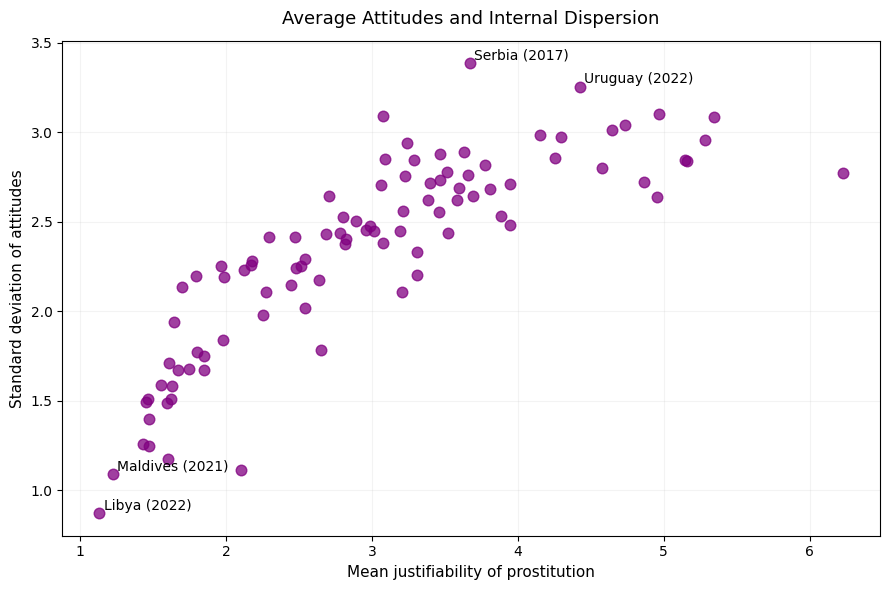

In [45]:
# Convert country codes to ISO3
def alpha2_to_alpha3(code):
    special = {"TW": "TWN", "HK": "HKG", "MO": "MAC", "NIR": None, "PR": None}
    if code in special:
        return special[code]
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

values["country_text_id"] = values["cntry_AN"].apply(alpha2_to_alpha3)

# Merge country names from democracy for labels
values_pol = values.merge(
    democracy.loc[:, ["country_name", "country_text_id", "year"]],
    on=["country_text_id", "year"],
    how="left"
)

plot_df = values_pol.dropna(subset=["F119_mean", "F119_sd"]).copy()

label_df = pd.concat([
    plot_df.nlargest(2, "F119_sd"),
    plot_df.nsmallest(2, "F119_sd")
]).drop_duplicates()

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(plot_df["F119_mean"], plot_df["F119_sd"], s=58, color="purple", alpha=0.75)

for _, row in label_df.iterrows():
    ax.text(
        row["F119_mean"] + 0.03,
        row["F119_sd"] + 0.02,
        f"{row['country_name']} ({int(row['year'])})",
        fontsize=10,
        color="black"
    )

ax.set_title("Average Attitudes and Internal Dispersion", fontsize=13, pad=12)
ax.set_xlabel("Mean justifiability of prostitution", fontsize=11)
ax.set_ylabel("Standard deviation of attitudes", fontsize=11)

ax.grid(True, alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(r"C:\Users\Ксения\Downloads\mean_vs_sd_values.png", dpi=300, bbox_inches="tight")
plt.show()